# 03 — Validación del ETL

El procesamiento ETL se ejecuta via scripts:
```bash
python scripts/prepare_mic.py        # mic fijos → predictions_geo.parquet
python scripts/prepare_mobile.py     # móvil → predictions_mobile.parquet
```
Este notebook valida la calidad del resultado **por trayecto** (no por día):
- **Mic**: trayecto = día de grabación (micrófono fijo)
- **Móvil**: trayecto = `session_id` (cada ruta es independiente; fecha extraída del GPX)

---

### Dos conjuntos de datos — cuándo se usa cada uno

| Variable | Origen | Contenido | Uso |
|---|---|---|---|
| `pred_geo` | `predictions_geo.parquet` | **Solo eventos con GPS asignado** (dataset de producción) | Secciones 1, 2, 4, 5, 6 |
| `pred_all_mic` / `pred_all_mob` | `predictions_mic/mobile.parquet` | **Todas las predicciones** (pre-filtro GPS, incluye audios de prueba) | Solo Sección 3 (calidad del join) |

> Las secciones de análisis de clases, mapas y estadísticas usan **únicamente `pred_geo`**.
> Los audios sin GPS asignado son sesiones de prueba o con fallo GPS y quedan excluidos.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

_dp = Path('../data/processed')
for _f in ['predictions_geo.parquet', 'tracks.parquet']:
    if not (_dp / _f).exists():
        raise FileNotFoundError(
            f"{_f} no encontrado.\nEjecutar primero:\n"
            "  python scripts/prepare_mic.py\n"
            "  python scripts/prepare_mobile.py  (opcional)"
        )

pred_geo = pd.read_parquet(_dp / 'predictions_geo.parquet')
tracks   = pd.read_parquet(_dp / 'tracks.parquet')

CLASS_NAMES = {0:"Horn",1:"Siren",2:"Pets",3:"Physiological",
               4:"Speech",5:"Ring Tone",6:"Vibrating",7:"Notifications",8:"Cry"}
pred_geo['class_name'] = pred_geo['class'].map(CLASS_NAMES)

# Columna trayecto: usar la del parquet si ya existe (prepare_mic.py actualizado),
# si no, derivar por compatibilidad con parquets antiguos.
def _trayecto(row):
    if row['source'] == 'mobile' and pd.notna(row.get('session_id')):
        return row['session_id']
    return row['date']

if 'trayecto' not in pred_geo.columns:
    pred_geo['trayecto'] = pred_geo.apply(_trayecto, axis=1)
if 'trayecto' not in tracks.columns:
    tracks['trayecto'] = tracks.apply(_trayecto, axis=1)

print(f"Eventos geolocalizados : {len(pred_geo)}")
print(f"Trackpoints GPS        : {len(tracks)}")
print(f"Fuentes                : {pred_geo['source'].value_counts().to_dict()}")
print(f"Trayectos mic          : {sorted(pred_geo[pred_geo['source']=='mic']['trayecto'].unique())}")
print(f"Trayectos movil        : {sorted(pred_geo[pred_geo['source']=='mobile']['trayecto'].unique()) if 'mobile' in pred_geo['source'].values else []}")

Eventos geolocalizados : 13223
Trackpoints GPS        : 28006
Fuentes                : {'mic': 9445, 'mobile': 3778}
Trayectos mic          : ['ETSE-PAIPORTA_1', 'ETSE-PAIPORTA_10', 'ETSE-PAIPORTA_11', 'ETSE-PAIPORTA_2', 'ETSE-PAIPORTA_3', 'ETSE-PAIPORTA_4', 'ETSE-PAIPORTA_5', 'ETSE-PAIPORTA_6', 'ETSE-PAIPORTA_7', 'ETSE-PAIPORTA_8', 'ETSE-PAIPORTA_9', 'PAIPORTA-ETSE_10', 'PAIPORTA-ETSE_11', 'PAIPORTA-ETSE_2', 'PAIPORTA-ETSE_3', 'PAIPORTA-ETSE_4', 'PAIPORTA-ETSE_5', 'PAIPORTA-ETSE_6', 'PAIPORTA-ETSE_7', 'PAIPORTA-ETSE_8', 'PAIPORTA-ETSE_9']
Trayectos movil        : ['20260523_ida', '20260523_vuelta', 'BURJASOT-SILLA', 'GYM-PAIPORTA', 'MALVARROSA-PAIPORTA', 'MASANASA-SILLA_1', 'MASANASA-SILLA_2_Revisar_GPS', 'PAIPORTA-GYM', 'PAIPORTA-MALVARROSA', 'PAIPORTA-SILLA_1', 'PAIPORTA-SILLA_2', 'SILLA-BURJASOT', 'SILLA-MASANASA_1', 'SILLA-MASANASA_2', 'SILLA-PAIPORTA_1']


## 1. Cobertura de Datos por Trayecto
¿Qué trayectos hay datos, de qué fuente y cuántos eventos?
- Mic: una fila por día de grabación
- Móvil: una fila por sesión (ruta distinta)

source,trayecto,mic,mobile,total
0,20260523_ida,0,67,67
1,20260523_vuelta,0,71,71
2,BURJASOT-SILLA,0,573,573
3,ETSE-PAIPORTA_1,298,0,298
4,ETSE-PAIPORTA_10,303,0,303
5,ETSE-PAIPORTA_11,458,0,458
6,ETSE-PAIPORTA_2,246,0,246
7,ETSE-PAIPORTA_3,934,0,934
8,ETSE-PAIPORTA_4,301,0,301
9,ETSE-PAIPORTA_5,302,0,302


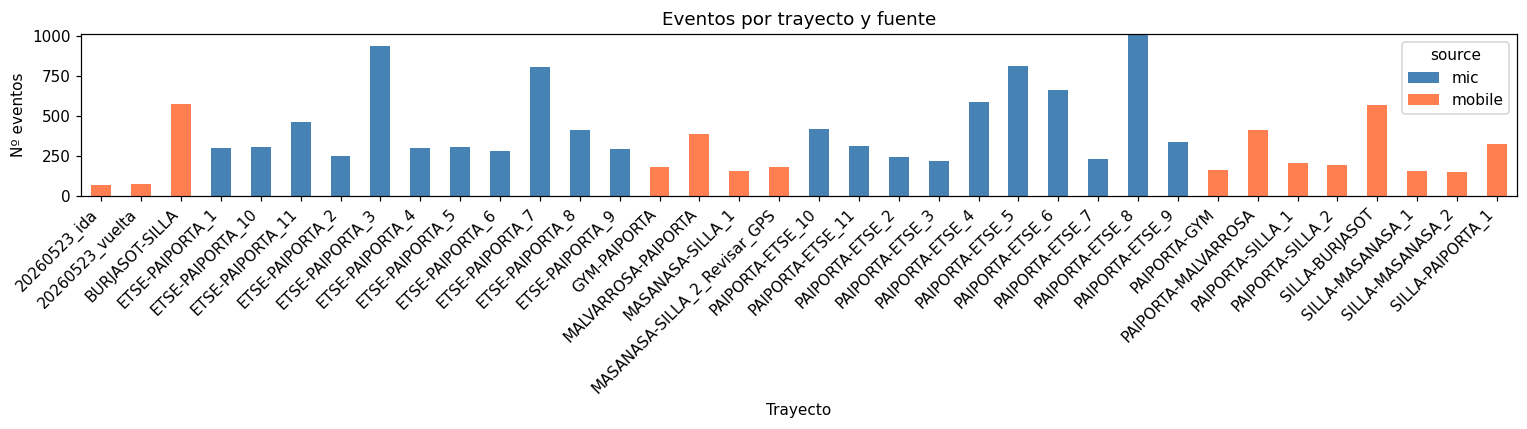

In [2]:
coverage = (
    pred_geo.groupby(['trayecto', 'source'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
coverage['total'] = coverage.drop(columns='trayecto').sum(axis=1)
coverage = coverage.sort_values('trayecto')
display(coverage)

src_cols = [c for c in coverage.columns if c not in ('trayecto', 'total')]
colors = {'mic': 'steelblue', 'mobile': 'coral'}
ax = coverage.set_index('trayecto')[src_cols].plot(
    kind='bar', stacked=True, figsize=(14, 4),
    color=[colors.get(c, 'gray') for c in src_cols],
    title='Eventos por trayecto y fuente'
)
ax.set_xlabel('Trayecto'); ax.set_ylabel('Nº eventos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Validación Temporal — Overlap GPS ↔ Predicciones por Trayecto

Comprueba que las predicciones caen dentro de la ventana temporal del GPS. Hora en **hora local (Europe/Madrid)**.

- `overlap_min ≤ 0` → desincronía audio/GPS
- `pct_geo < 80%` → más del 20% de predicciones de esa fecha sin GPS asignado (fallo de join)
- Columna `fecha` → fecha real del trayecto (mapea PAIPORTA-ETSE_N → día de grabación)

In [3]:
# Cargar totales pre-join (solo columnas necesarias) para calcular cobertura GPS
_pred_all_mic_s2 = (
    pd.read_parquet(_dp / 'predictions_mic.parquet', columns=['date'])
    if (_dp / 'predictions_mic.parquet').exists() else pd.DataFrame(columns=['date'])
)
_pred_all_mob_s2 = (
    pd.read_parquet(_dp / 'predictions_mobile.parquet', columns=['session_id'])
    if (_dp / 'predictions_mobile.parquet').exists() else pd.DataFrame(columns=['session_id'])
)
_date_totals = _pred_all_mic_s2.groupby('date').size().to_dict()
_sid_totals  = _pred_all_mob_s2.groupby('session_id').size().to_dict() if 'session_id' in _pred_all_mob_s2.columns else {}

results = []
for (trayecto, source), grp in pred_geo.groupby(['trayecto', 'source']):
    # Excluir trayectos sin GPS real (skip / noaudio del ETL)
    if any(s in trayecto for s in ('_skip', '_noaudio')):
        continue

    trk_seg = tracks[tracks['trayecto'] == trayecto]
    if trk_seg.empty:
        continue

    gps_min, gps_max = trk_seg['time'].min(), trk_seg['time'].max()
    pred_min, pred_max = grp['t_start'].min(), grp['t_start'].max()

    overlap   = (min(gps_max, pred_max) - max(gps_min, pred_min)).total_seconds() / 60
    dur_gps   = (gps_max - gps_min).total_seconds() / 60
    fecha_gps = gps_min.tz_convert('Europe/Madrid').strftime('%d-%m-%Y')

    # Cobertura GPS: n geolocalizados / total pre-join para esa fecha/sesión
    if source == 'mic':
        n_total = _date_totals.get(grp['date'].iloc[0], len(grp))
    else:
        n_total = _sid_totals.get(trayecto, len(grp))
    pct_geo = len(grp) / n_total * 100 if n_total > 0 else 0

    label = trayecto + (' ⚠GPS?' if '_Revisar' in trayecto else '')
    results.append({
        'trayecto':    label,
        'fecha':       fecha_gps,
        'source':      source,
        'gps_ini':     gps_min.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'gps_fin':     gps_max.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'dur_gps_min': round(dur_gps, 1),
        'pred_ini':    pred_min.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'pred_fin':    pred_max.tz_convert('Europe/Madrid').strftime('%H:%M'),
        'n_geo':       len(grp),
        'n_total':     n_total,
        'pct_geo':     round(pct_geo, 1),
        'overlap_min': round(overlap, 1),
    })

df_overlap = pd.DataFrame(results)
df_overlap['_date_sort'] = pd.to_datetime(df_overlap['fecha'], format='%d-%m-%Y', errors='coerce')
df_overlap = df_overlap.sort_values(['source', '_date_sort']).drop(columns=['_date_sort'])

def _style_s2(row):
    styles = [''] * len(row)
    cols = row.index.tolist()
    if row['overlap_min'] <= 0 and 'overlap_min' in cols:
        styles[cols.index('overlap_min')] = 'background-color: #ffcccc'
    if 'pct_geo' in cols:
        if row['pct_geo'] < 50:
            styles[cols.index('pct_geo')] = 'background-color: #ffcccc'
        elif row['pct_geo'] < 80:
            styles[cols.index('pct_geo')] = 'background-color: #fff3cd'
    return styles

display(df_overlap.style.apply(_style_s2, axis=1))

bad_overlap  = df_overlap[df_overlap['overlap_min'] <= 0]
bad_coverage = df_overlap[df_overlap['pct_geo'] < 50]

if len(bad_overlap):
    print("\n⚠ Sin solapamiento GPS-predicciones:")
    for _, r in bad_overlap.iterrows():
        print(f"  {r['trayecto']} [{r['fecha']}] — GPS {r['gps_ini']}-{r['gps_fin']} | Pred {r['pred_ini']}-{r['pred_fin']}")
else:
    print("\n✓ Todos los trayectos tienen solapamiento temporal GPS ↔ predicciones.")

if len(bad_coverage):
    print(f"\n⚠ Cobertura GPS baja (<50%) — valorar excluir del análisis:")
    for _, r in bad_coverage.iterrows():
        print(f"  {r['trayecto']} [{r['fecha']}]: {r['pct_geo']:.1f}% ({r['n_geo']}/{r['n_total']})")
else:
    print("\n✓ Todos los trayectos con cobertura GPS ≥ 50%.")

,trayecto,fecha,source,gps_ini,gps_fin,dur_gps_min,pred_ini,pred_fin,n_geo,n_total,pct_geo,overlap_min
3,ETSE-PAIPORTA_1,11-03-2026,mic,20:22,20:38,15.400000,20:22,20:37,298,596,50.000000,15.300000
6,ETSE-PAIPORTA_2,23-03-2026,mic,19:25,19:42,16.800000,19:25,19:42,246,639,38.500000,16.800000
20,PAIPORTA-ETSE_2,23-03-2026,mic,15:10,15:36,25.900000,15:10,15:36,243,639,38.000000,25.100000
7,ETSE-PAIPORTA_3,30-03-2026,mic,19:31,19:49,18.300000,19:31,19:49,934,1435,65.100000,17.800000
21,PAIPORTA-ETSE_3,30-03-2026,mic,15:15,15:39,23.700000,15:15,15:38,215,1435,15.000000,23.100000
8,ETSE-PAIPORTA_4,01-04-2026,mic,20:04,20:24,19.900000,20:05,20:24,301,1228,24.500000,19.300000
22,PAIPORTA-ETSE_4,01-04-2026,mic,14:48,15:08,19.100000,14:48,15:06,584,1228,47.600000,17.800000
9,ETSE-PAIPORTA_5,14-04-2026,mic,19:51,20:07,16.200000,19:51,20:06,302,1481,20.400000,15.300000
23,PAIPORTA-ETSE_5,14-04-2026,mic,17:09,17:30,20.600000,17:09,17:29,813,1481,54.900000,19.900000
10,ETSE-PAIPORTA_6,15-04-2026,mic,19:12,19:30,18.200000,19:11,19:29,277,1332,20.800000,17.100000



✓ Todos los trayectos tienen solapamiento temporal GPS ↔ predicciones.

⚠ Cobertura GPS baja (<50%) — valorar excluir del análisis:
  ETSE-PAIPORTA_2 [23-03-2026]: 38.5% (246/639)
  PAIPORTA-ETSE_2 [23-03-2026]: 38.0% (243/639)
  PAIPORTA-ETSE_3 [30-03-2026]: 15.0% (215/1435)
  ETSE-PAIPORTA_4 [01-04-2026]: 24.5% (301/1228)
  PAIPORTA-ETSE_4 [01-04-2026]: 47.6% (584/1228)
  ETSE-PAIPORTA_5 [14-04-2026]: 20.4% (302/1481)
  ETSE-PAIPORTA_6 [15-04-2026]: 20.8% (277/1332)
  PAIPORTA-ETSE_6 [15-04-2026]: 49.4% (658/1332)
  PAIPORTA-ETSE_7 [16-04-2026]: 18.1% (232/1281)
  ETSE-PAIPORTA_8 [20-04-2026]: 22.2% (412/1855)
  ETSE-PAIPORTA_9 [22-04-2026]: 37.5% (291/775)
  PAIPORTA-ETSE_9 [22-04-2026]: 43.4% (336/775)
  ETSE-PAIPORTA_10 [23-04-2026]: 32.8% (303/923)
  PAIPORTA-ETSE_10 [23-04-2026]: 45.2% (417/923)
  ETSE-PAIPORTA_11 [24-04-2026]: 46.4% (458/988)
  PAIPORTA-ETSE_11 [24-04-2026]: 31.6% (312/988)


## 3. Calidad del Join — % Geolocalizados por Trayecto

> ⚠️ **Esta sección usa `pred_all_mic` / `pred_all_mob`** (todas las predicciones, pre-filtro GPS)
> para calcular cuántas se perdieron por falta de trackpoint GPS.
> El resto del notebook usa solo `pred_geo` (GPS asignado).

In [4]:
# Calidad del join: predicciones totales (pre-join, TODAS) vs geolocalizadas (pred_geo, GPS-only)
# pred_all_mic / pred_all_mob = todas las predicciones antes del filtro GPS
# pred_geo = solo eventos con GPS asignado (dataset de producción)

pred_all_mic = pd.read_parquet(_dp / 'predictions_mic.parquet') if (_dp/'predictions_mic.parquet').exists() else pd.DataFrame()
_pred_mob_path = _dp / 'predictions_mobile.parquet'
pred_all_mob = pd.read_parquet(_pred_mob_path) if _pred_mob_path.exists() else pd.DataFrame()

# Resumen global pre/post GPS
total_raw = len(pred_all_mic) + len(pred_all_mob)
total_geo = len(pred_geo)
print(f"=== Pre-filtro GPS (todas las predicciones) ===")
print(f"  Mic   : {len(pred_all_mic)}")
print(f"  Mobile: {len(pred_all_mob)}")
print(f"  Total : {total_raw}")
print(f"\n=== Post-filtro GPS (pred_geo — dataset de producción) ===")
print(f"  Total geolocalizados : {total_geo}  ({total_geo/max(1,total_raw):.1%})")
print(f"  Descartados sin GPS  : {total_raw - total_geo}")
print()

quality = []

# Mic: comparar por DATE — incluye fechas sin GPS (aparecen como 0%)
if not pred_all_mic.empty:
    for date, grp in pred_all_mic.groupby('date'):
        geo_date = pred_geo[(pred_geo['source'] == 'mic') & (pred_geo['date'] == date)]
        total = len(grp)
        joined = len(geo_date)
        traj_list = ', '.join(sorted(geo_date['trayecto'].unique())) if joined else '(sin GPS)'
        quality.append({
            'fecha':          date,
            'trayecto':       traj_list,
            'source':         'mic',
            'total_preds':    total,
            'geolocalizados': joined,
            'descartados':    total - joined,
            'pct':            f"{joined/total*100:.1f}%" if total else "0%",
        })

# Mobile: comparar por session_id
if not pred_all_mob.empty:
    _pred_mob2 = pred_all_mob.rename(columns={'timestamp_onset': 't_start', 'class_id': 'class'})
    _pred_mob2['t_start'] = pd.to_datetime(_pred_mob2['t_start'], utc=True)
    for sid, grp in _pred_mob2.groupby('session_id'):
        geo_sid = pred_geo[(pred_geo['source'] == 'mobile') & (pred_geo['trayecto'] == sid)]
        total = len(grp)
        joined = len(geo_sid)
        quality.append({
            'fecha':          '-',
            'trayecto':       sid,
            'source':         'mobile',
            'total_preds':    total,
            'geolocalizados': joined,
            'descartados':    total - joined,
            'pct':            f"{joined/total*100:.1f}%" if total else "0%",
        })

df_q = pd.DataFrame(quality)

# Ordenar cronológicamente: mic por fecha real, mobile por trayecto
df_q['_sort'] = df_q.apply(
    lambda r: pd.to_datetime(r['fecha'], format='%d-%m-%Y', errors='coerce')
              if r['source'] == 'mic' else pd.NaT,
    axis=1
)
df_q = (
    pd.concat([
        df_q[df_q['source']=='mic'].sort_values('_sort'),
        df_q[df_q['source']=='mobile'].sort_values('trayecto'),
    ])
    .drop(columns=['_sort'])
    .reset_index(drop=True)
)

display(df_q.style.apply(
    lambda col: [
        'background-color: #ffcccc' if float(v.rstrip('%')) < 70 else
        'background-color: #fff3cd' if float(v.rstrip('%')) < 90 else ''
        for v in col
    ] if col.name == 'pct' else ['']*len(col), axis=0
))

mic_geo = pred_geo[pred_geo['source'] == 'mic']
if not mic_geo.empty:
    print("\nEventos mic por microfono (pred_geo):")
    print(mic_geo['microfono_id'].value_counts().to_string())

=== Pre-filtro GPS (todas las predicciones) ===
  Mic   : 19754
  Mobile: 4118
  Total : 23872

=== Post-filtro GPS (pred_geo — dataset de producción) ===
  Total geolocalizados : 13223  (55.4%)
  Descartados sin GPS  : 10649



,fecha,trayecto,source,total_preds,geolocalizados,descartados,pct
0,05-03-2026,(sin GPS),mic,77,0,77,0.0%
1,06-03-2026,(sin GPS),mic,102,0,102,0.0%
2,08-03-2026,(sin GPS),mic,10,0,10,0.0%
3,10-03-2026,(sin GPS),mic,449,0,449,0.0%
4,11-03-2026,ETSE-PAIPORTA_1,mic,596,298,298,50.0%
5,23-03-2026,"ETSE-PAIPORTA_2, PAIPORTA-ETSE_2",mic,639,489,150,76.5%
6,24-03-2026,(sin GPS),mic,414,0,414,0.0%
7,30-03-2026,"ETSE-PAIPORTA_3, PAIPORTA-ETSE_3",mic,1435,1149,286,80.1%
8,01-04-2026,"ETSE-PAIPORTA_4, PAIPORTA-ETSE_4",mic,1228,885,343,72.1%
9,11-04-2026,(sin GPS),mic,383,0,383,0.0%



Eventos mic por microfono (pred_geo):
microfono_id
1    5316
2    4129


## 4. Distribución de Clases por Fuente  *(solo `pred_geo` — eventos con GPS)*

Comparación mic vs móvil: ¿detectan las mismas clases con la misma frecuencia?
Los audios de prueba (sin GPS asignado) quedan excluidos.

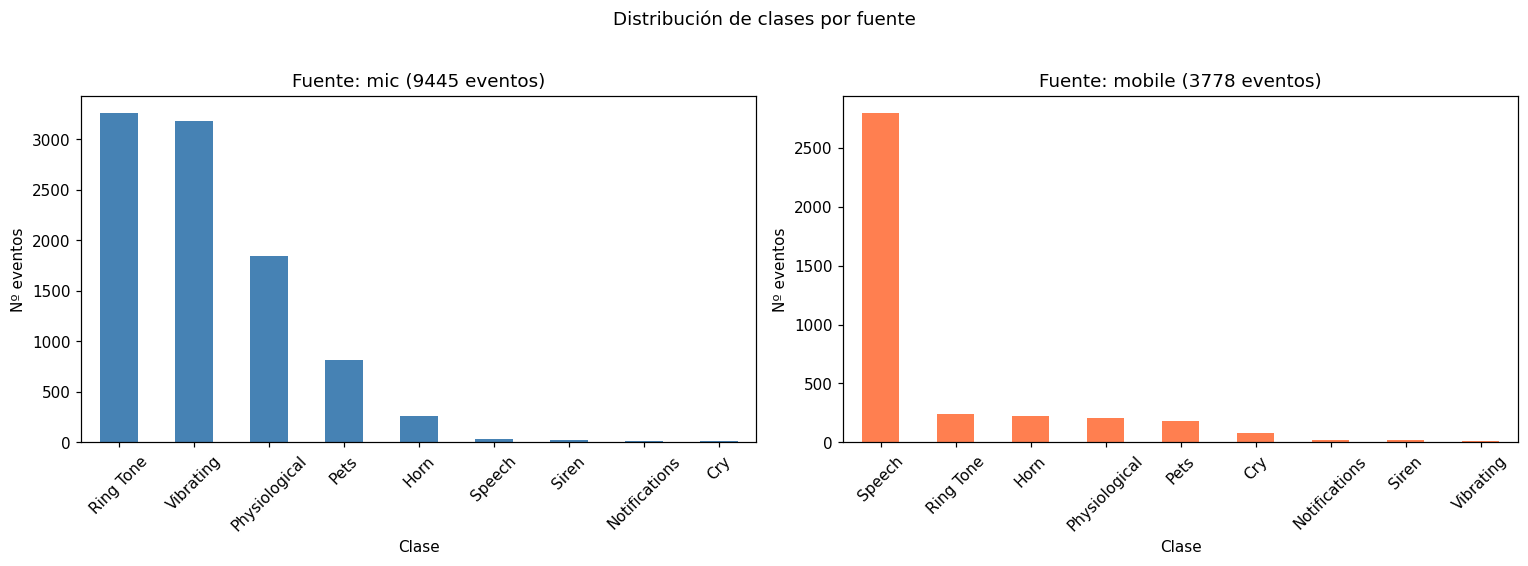

In [5]:
sources = pred_geo['source'].unique()
if len(sources) > 1:
    fig, axes = plt.subplots(1, len(sources), figsize=(14, 5), sharey=False)
    for ax, src in zip(axes, sorted(sources)):
        grp = pred_geo[pred_geo['source'] == src]
        counts = grp['class_name'].value_counts()
        counts.plot(kind='bar', ax=ax, color='steelblue' if src == 'mic' else 'coral')
        ax.set_title(f'Fuente: {src} ({len(grp)} eventos)')
        ax.set_xlabel('Clase'); ax.set_ylabel('Nº eventos')
        ax.tick_params(axis='x', rotation=45)
    plt.suptitle('Distribución de clases por fuente', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    pred_geo['class_name'].value_counts().plot(
        kind='bar', figsize=(10, 4), color='steelblue',
        title=f'Distribución de clases (fuente: {sources[0]})'
    )
    plt.xlabel('Clase'); plt.ylabel('Nº eventos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5. Anomalias Conocidas

- **11-03-2026** [mic]: excluido del contador de trayectos (`SKIP_DATES` en `prepare_mic.py`). GPS existe pero sin solapamiento temporal con predicciones (desfase timestamp audio). Trackpoints guardados como `11-03-2026_skip1/2` en `tracks_mic.parquet`.
- **20/22/23/24-04-2026** [mic]: GPX existe pero sin audio procesado en `data/clean/`. Trayectos marcados como `noaudio` en `tracks_mic.parquet`. No aparecen en `predictions_geo.parquet`.
- **Trayectos nombrados Mic**: PAIPORTA-ETSE_1..6 (mañana) y ETSE-PAIPORTA_1..6 (tarde), correspondientes a 23-03-2026 → 16-04-2026.
- **NMS cruzado M1/M2**: `prepare_mic.py` elimina predicciones duplicadas entre microfono frontal y trasero (IoU temporal >= 0.3, ventana +-1s). Reduccion tipica ~17%.

## 6. Distribución de Clases por Trayecto  *(solo `pred_geo` — eventos con GPS)*

Análisis de la distribución cruda (sin umbral de confianza). Permite detectar trayectos con clases inusualmente elevadas o anomalías de clasificación.

> **Nota**: Speech, Vibrating y Ring Tone suelen dominar en grabaciones de vehículo (ruido de motor, radio, conversaciones). Horn y Siren son minoritarios pero son los indicadores de peligro del estudio. El umbral 0.8 en NB02 filtra gran parte del ruido.

## 7. Tasa de Detección por Trayecto (eventos/min)

Normaliza el número de detecciones por la duración real de cada sesión GPS, eliminando el sesgo de longitud de trayecto.

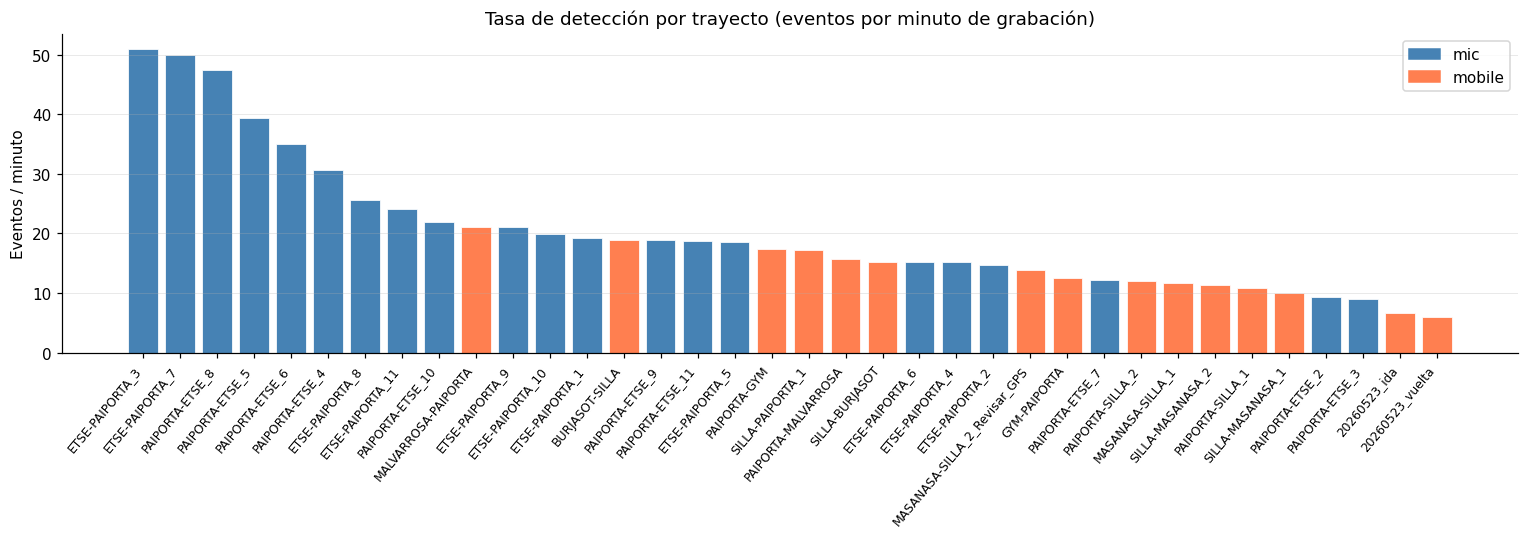

Saved: outputs/trayecto_distribution_per_min.png


,trayecto,n_eventos,duracion_min,ev_por_min
0,ETSE-PAIPORTA_3,934,18.32,50.99
1,ETSE-PAIPORTA_7,804,16.10,49.94
2,PAIPORTA-ETSE_8,1009,21.30,47.37
3,PAIPORTA-ETSE_5,813,20.63,39.40
4,PAIPORTA-ETSE_6,658,18.75,35.09
5,PAIPORTA-ETSE_4,584,19.10,30.58
6,ETSE-PAIPORTA_8,412,16.05,25.67
7,ETSE-PAIPORTA_11,458,19.05,24.04
8,PAIPORTA-ETSE_10,417,19.05,21.89
9,MALVARROSA-PAIPORTA,389,18.43,21.10


In [6]:
# ── 7a. Duración GPS por trayecto ────────────────────────────────────────────
dur_gps = (
    tracks.groupby("trayecto")["time"]
    .agg(lambda x: (x.max() - x.min()).total_seconds() / 60.0)
    .rename("duration_min")
)

# ── 7b. Eventos por trayecto y tasa normalizada ───────────────────────────────
cnt = pred_geo.groupby("trayecto").size().rename("count")
merged = cnt.to_frame().join(dur_gps, how="inner")
merged["events_per_min"] = merged["count"] / merged["duration_min"].clip(lower=1)
merged = merged.sort_values("events_per_min", ascending=False).reset_index()

# Fuente por trayecto (para colorear)
src_map = pred_geo.groupby("trayecto")["source"].first()
mic_trayectos = set(src_map[src_map == "mic"].index)

# ── 7c. Figura ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ["steelblue" if t in mic_trayectos else "coral" for t in merged["trayecto"]]
ax.bar(range(len(merged)), merged["events_per_min"],
       color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(merged)))
ax.set_xticklabels(merged["trayecto"], rotation=50, ha="right", fontsize=8)
ax.set_ylabel("Eventos / minuto")
ax.set_title("Tasa de detección por trayecto (eventos por minuto de grabación)")
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="mic"),
                   Patch(color="coral",     label="mobile")])
plt.tight_layout()
plt.savefig("../outputs/trayecto_distribution_per_min.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/trayecto_distribution_per_min.png")

display(merged[["trayecto","count","duration_min","events_per_min"]].rename(
    columns={"count":"n_eventos","duration_min":"duracion_min","events_per_min":"ev_por_min"}
).round(2))

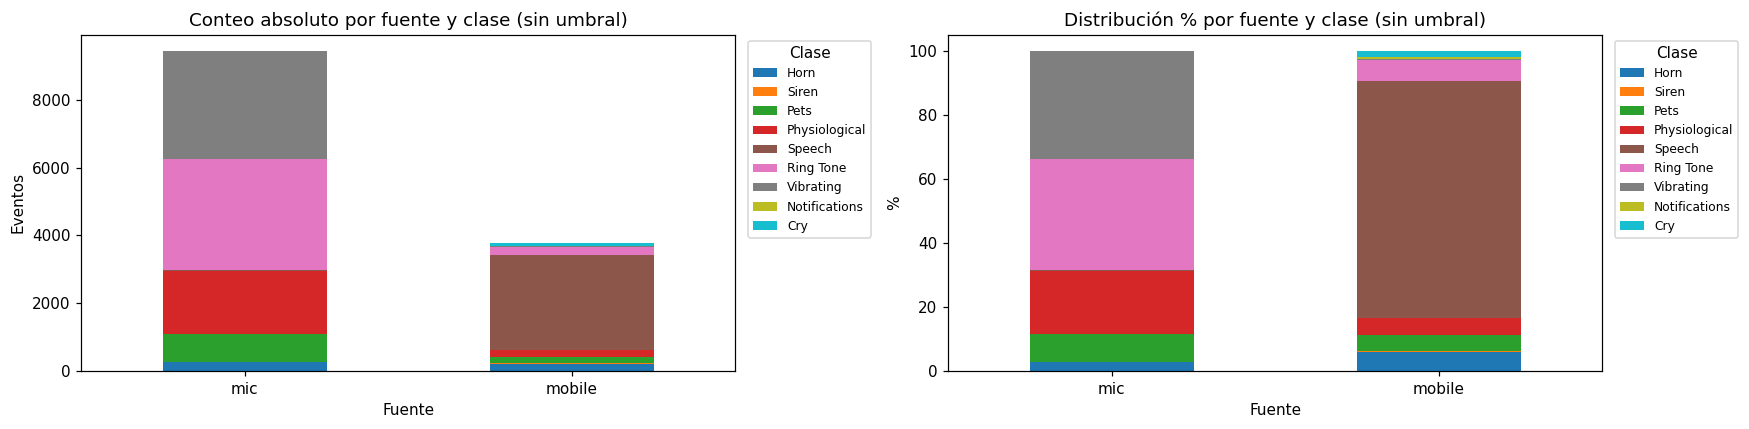

Distribución % (sin umbral):


class_name,Horn,Siren,Pets,Physiological,Speech,Ring Tone,Vibrating,Notifications,Cry
source,,,,,,,,,
mic,2.8,0.3,8.7,19.5,0.3,34.5,33.7,0.1,0.1
mobile,5.9,0.4,4.8,5.4,74.1,6.4,0.2,0.6,2.1


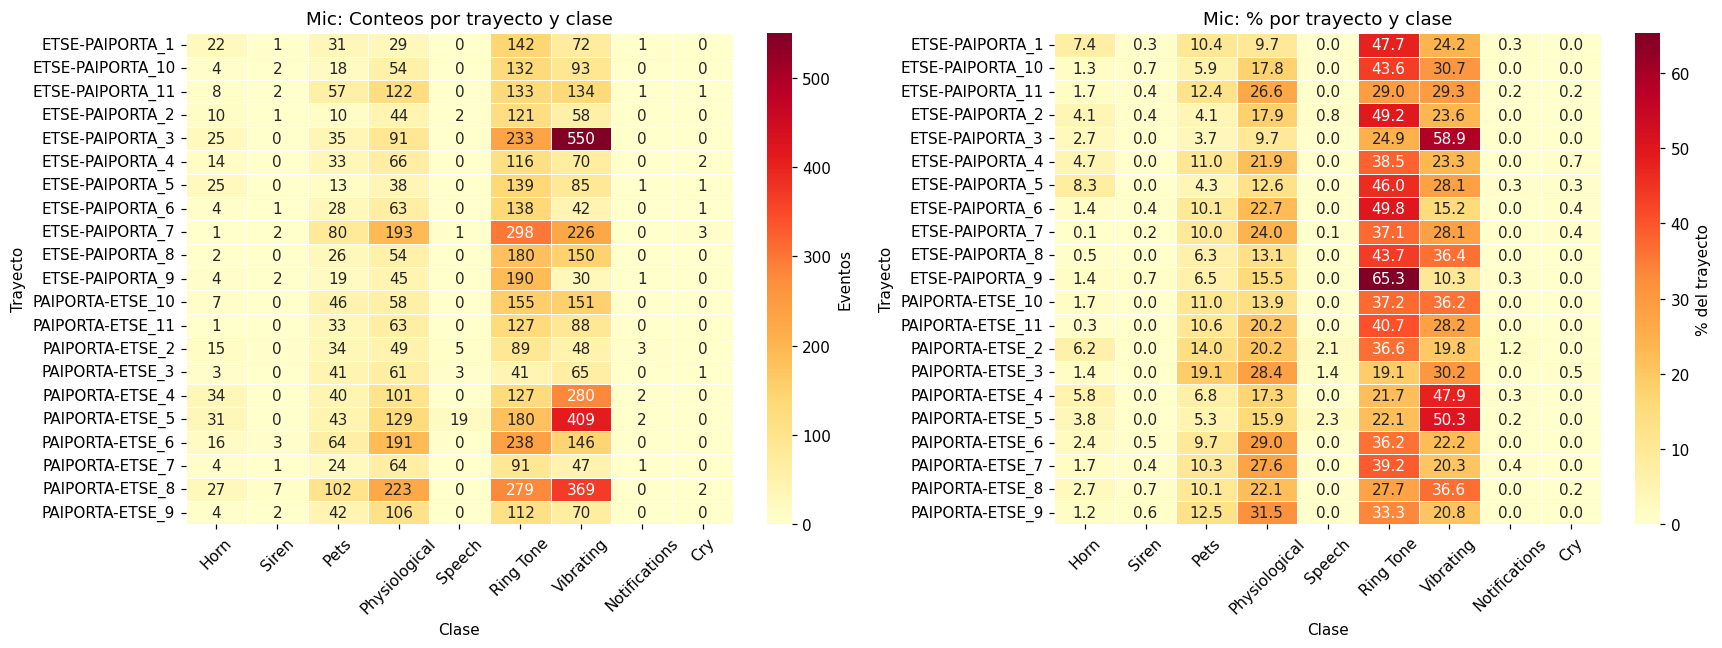

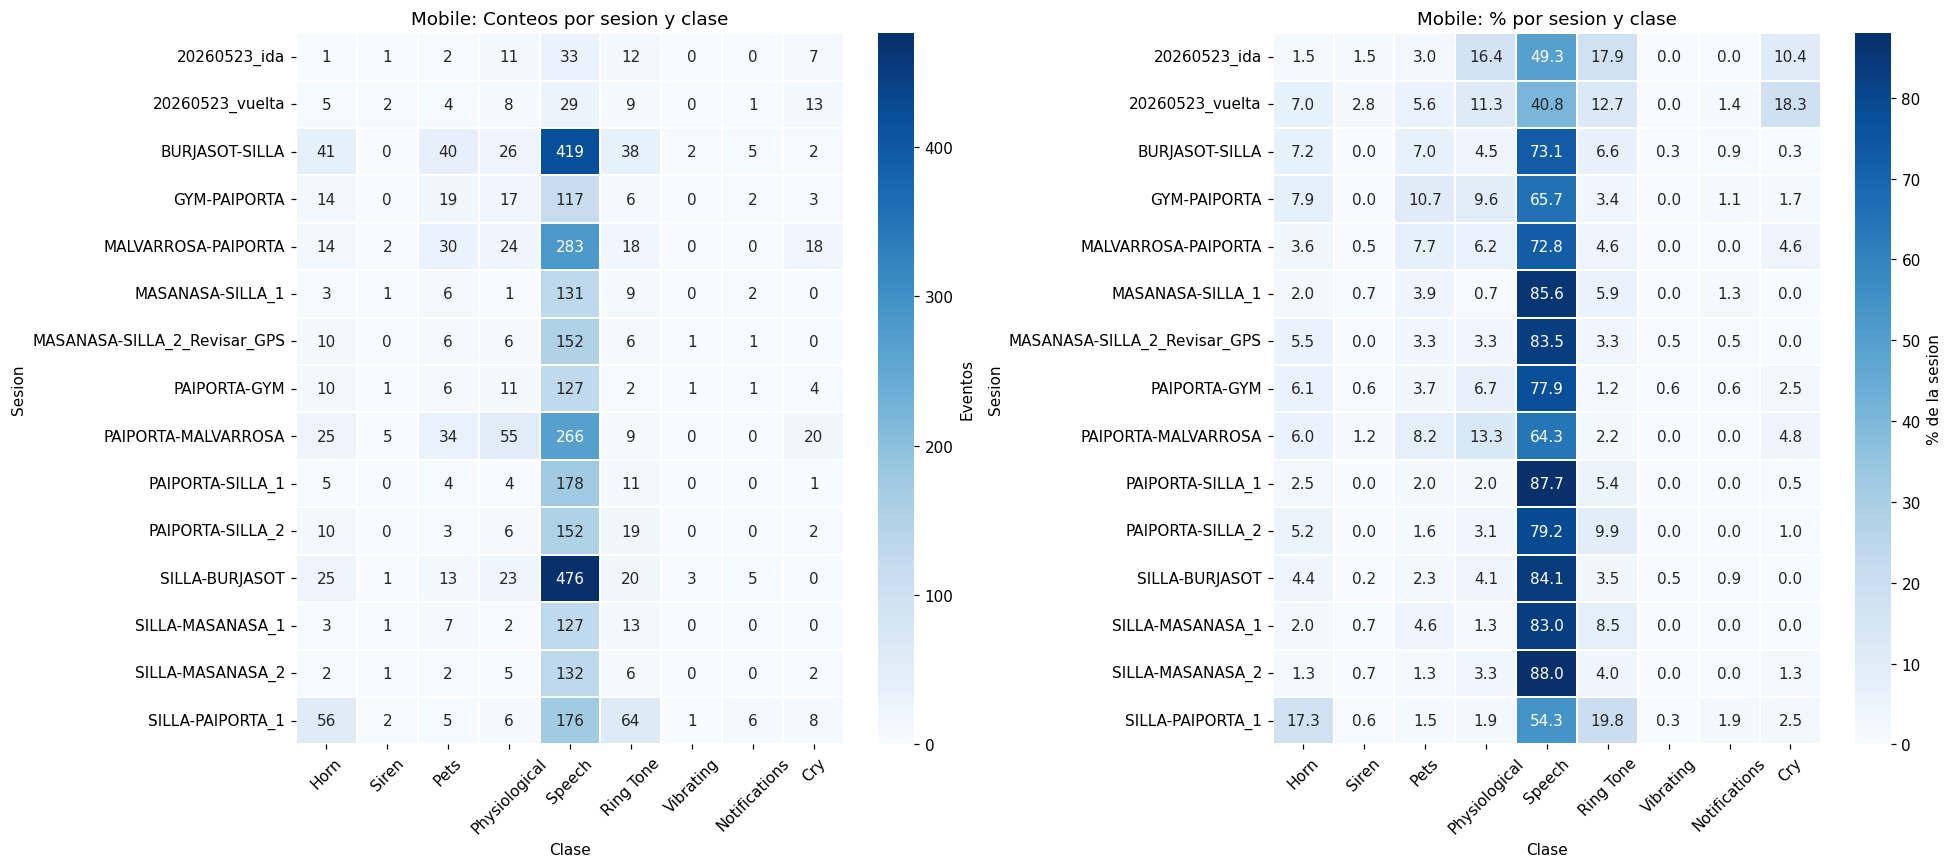


Confianza media por clase y fuente:


conf_media  conf_std     n
source class_name                               
mic    Cry                 0.171     0.064    11
       Horn                0.300     0.209   261
       Notifications       0.254     0.152    12
       Pets                0.256     0.163   819
       Physiological       0.278     0.177  1844
       Ring Tone           0.319     0.176  3261
       Siren               0.286     0.208    24
       Speech              0.359     0.179    30
       Vibrating           0.386     0.247  3183
mobile Cry                 0.267     0.141    80
       Horn                0.282     0.193   224
       Notifications       0.290     0.203    23
       Pets                0.257     0.162   181
       Physiological       0.254     0.158   205
       Ring Tone           0.394     0.205   242
       Siren               0.381     0.167    17
       Speech              0.478     0.258  2798
       Vibrating           0.193     0.133     8


Clases con confianza media < 0.3 (posible ruido):


conf_media  conf_std     n
source class_name                               
mic    Cry                 0.171     0.064    11
       Notifications       0.254     0.152    12
       Pets                0.256     0.163   819
       Physiological       0.278     0.177  1844
       Siren               0.286     0.208    24
mobile Cry                 0.267     0.141    80
       Horn                0.282     0.193   224
       Notifications       0.290     0.203    23
       Pets                0.257     0.162   181
       Physiological       0.254     0.158   205
       Vibrating           0.193     0.133     8

In [7]:
import seaborn as sns
import numpy as np

CLASS_ORDER = ['Horn', 'Siren', 'Pets', 'Physiological', 'Speech',
               'Ring Tone', 'Vibrating', 'Notifications', 'Cry']

# ── 1. Porcentaje por clase y fuente ─────────────────────────────────────────
pct_src = (
    pred_geo.groupby(['source', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
pct_src_norm = pct_src.div(pct_src.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Conteos absolutos
pct_src.plot(kind='bar', ax=axes[0], colormap='tab10', stacked=True)
axes[0].set_title('Conteo absoluto por fuente y clase (sin umbral)')
axes[0].set_xlabel('Fuente')
axes[0].set_ylabel('Eventos')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Porcentaje
pct_src_norm.plot(kind='bar', ax=axes[1], colormap='tab10', stacked=True)
axes[1].set_title('Distribución % por fuente y clase (sin umbral)')
axes[1].set_xlabel('Fuente')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print("Distribución % (sin umbral):")
display(pct_src_norm.round(1))

# ── 2. Heatmap trayecto × clase (Mic) — % normalizado por trayecto ───────────
mic_traj = (
    pred_geo[pred_geo['source'] == 'mic']
    .groupby(['trayecto', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
mic_traj_pct = mic_traj.div(mic_traj.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mic_traj, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Eventos'})
axes[0].set_title('Mic: Conteos por trayecto y clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Trayecto')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(mic_traj_pct.round(1), annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% del trayecto'})
axes[1].set_title('Mic: % por trayecto y clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Trayecto')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 3. Heatmap trayecto × clase (Mobile) ─────────────────────────────────────
mob_traj = (
    pred_geo[pred_geo['source'] == 'mobile']
    .groupby(['trayecto', 'class_name']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
mob_traj_pct = mob_traj.div(mob_traj.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(mob_traj, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, cbar_kws={'label': 'Eventos'})
axes[0].set_title('Mobile: Conteos por sesion y clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Sesion')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(mob_traj_pct.round(1), annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.3, cbar_kws={'label': '% de la sesion'})
axes[1].set_title('Mobile: % por sesion y clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Sesion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 4. Confianza media por clase y fuente ─────────────────────────────────────
conf_stats = pred_geo.groupby(['source', 'class_name'])['confidence'].agg(['mean', 'std', 'count']).round(3)
conf_stats.columns = ['conf_media', 'conf_std', 'n']
print("\nConfianza media por clase y fuente:")
display(conf_stats)

# Flag: clases con confianza media baja (<0.3) → probable ruido
low_conf = conf_stats[conf_stats['conf_media'] < 0.3]
if not low_conf.empty:
    print("\nClases con confianza media < 0.3 (posible ruido):")
    display(low_conf)

## 8. Diagnóstico: Speech Detection Anomaly

Análisis detallado de las 7000+ predicciones de Speech para identificar:
- Distribución de confianza
- Qué trayectos las generan
- Si son falsos positivos (confianza baja)

=== SPEECH ANALYSIS ===
Total Speech en pred_geo (con GPS): 2828
Total Speech en raw (pre-GPS): 0
% del total pred_geo: 21.4%

Distribución de CONFIANZA en Speech:
  Media: 0.477
  Mediana: 0.471
  Mín: 0.100
  Máx: 0.970
  < 0.3: 910
  0.3-0.5: 589
  0.5-0.7: 586
  >= 0.7: 743

Top 10 trayectos con MÁS predicciones Speech:
  SILLA-BURJASOT [mobile]: 476 eventos (conf_media=0.53)
  BURJASOT-SILLA [mobile]: 419 eventos (conf_media=0.50)
  MALVARROSA-PAIPORTA [mobile]: 283 eventos (conf_media=0.48)
  PAIPORTA-MALVARROSA [mobile]: 266 eventos (conf_media=0.45)
  PAIPORTA-SILLA_1 [mobile]: 178 eventos (conf_media=0.49)
  SILLA-PAIPORTA_1 [mobile]: 176 eventos (conf_media=0.44)
  MASANASA-SILLA_2_Revisar_GPS [mobile]: 152 eventos (conf_media=0.49)
  PAIPORTA-SILLA_2 [mobile]: 152 eventos (conf_media=0.41)
  SILLA-MASANASA_2 [mobile]: 132 eventos (conf_media=0.45)
  MASANASA-SILLA_1 [mobile]: 131 eventos (conf_media=0.49)



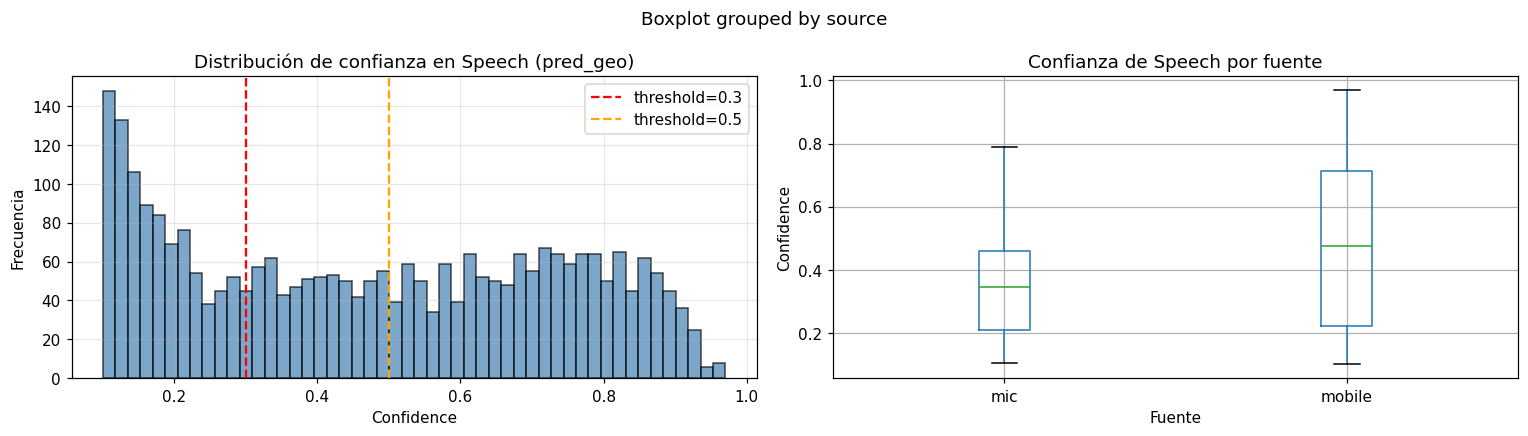

Confianza de Speech POR FUENTE:

  MIC: 30 eventos
    Media conf: 0.359
    < 0.3: 10
    < 0.5: 26
    >= 0.7: 2

  MOBILE: 2798 eventos
    Media conf: 0.478
    < 0.3: 900
    < 0.5: 1473
    >= 0.7: 741


In [8]:
speech_preds = pred_geo[pred_geo['class_name'] == 'Speech'].copy()
speech_all = pred_all_mic[pred_all_mic['class_id'] == 4] if 'class_id' in pred_all_mic.columns else pd.DataFrame()

print(f"=== SPEECH ANALYSIS ===")
print(f"Total Speech en pred_geo (con GPS): {len(speech_preds)}")
print(f"Total Speech en raw (pre-GPS): {len(speech_all)}")
print(f"% del total pred_geo: {len(speech_preds)/len(pred_geo)*100:.1f}%")
print()

# 1. Distribución de confianza
print("Distribución de CONFIANZA en Speech:")
print(f"  Media: {speech_preds['confidence'].mean():.3f}")
print(f"  Mediana: {speech_preds['confidence'].median():.3f}")
print(f"  Mín: {speech_preds['confidence'].min():.3f}")
print(f"  Máx: {speech_preds['confidence'].max():.3f}")
print(f"  < 0.3: {len(speech_preds[speech_preds['confidence'] < 0.3])}")
print(f"  0.3-0.5: {len(speech_preds[(speech_preds['confidence'] >= 0.3) & (speech_preds['confidence'] < 0.5)])}")
print(f"  0.5-0.7: {len(speech_preds[(speech_preds['confidence'] >= 0.5) & (speech_preds['confidence'] < 0.7)])}")
print(f"  >= 0.7: {len(speech_preds[speech_preds['confidence'] >= 0.7])}")
print()

# 2. Por trayecto
print("Top 10 trayectos con MÁS predicciones Speech:")
speech_by_traj = speech_preds.groupby('trayecto').size().sort_values(ascending=False)
for traj, cnt in speech_by_traj.head(10).items():
    src = speech_preds[speech_preds['trayecto'] == traj]['source'].iloc[0]
    conf_mean = speech_preds[speech_preds['trayecto'] == traj]['confidence'].mean()
    print(f"  {traj} [{src}]: {cnt} eventos (conf_media={conf_mean:.2f})")
print()

# 3. Histograma de confianza
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(speech_preds['confidence'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.3, color='red', linestyle='--', label='threshold=0.3')
axes[0].axvline(0.5, color='orange', linestyle='--', label='threshold=0.5')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de confianza en Speech (pred_geo)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot por fuente
if 'mobile' in speech_preds['source'].values and 'mic' in speech_preds['source'].values:
    speech_preds.boxplot(column='confidence', by='source', ax=axes[1])
    axes[1].set_xlabel('Fuente')
    axes[1].set_ylabel('Confidence')
    axes[1].set_title('Confianza de Speech por fuente')
    plt.sca(axes[1])
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 4. Estadísticas por fuente
print("Confianza de Speech POR FUENTE:")
for src in speech_preds['source'].unique():
    src_speech = speech_preds[speech_preds['source'] == src]
    print(f"\n  {src.upper()}: {len(src_speech)} eventos")
    print(f"    Media conf: {src_speech['confidence'].mean():.3f}")
    print(f"    < 0.3: {len(src_speech[src_speech['confidence'] < 0.3])}")
    print(f"    < 0.5: {len(src_speech[src_speech['confidence'] < 0.5])}")
    print(f"    >= 0.7: {len(src_speech[src_speech['confidence'] >= 0.7])}")